# Case Study II: 2024 KATL Taxiway Collision:

 - The incident occurred on Sept. 10 at approximately 10:07 a.m. as two aircraft, Delta Air Lines flight 295, an Airbus A350-941 (N503DN), and Endeavor Air flight 5526 (operating as Delta), a Mitsubishi CRJ-900 (N302PQ), collided while taxiing for departure.
 - https://www.fox5atlanta.com/news/ntsb-preliminary-report-two-delta-planes-collided-atlanta-airports-taxiway

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import spacy

nlp_ner = spacy.load("./transformer/model-best")
ruler = nlp_ner.add_pipe(
    "entity_ruler",
    after="ner",  # or before="ner"
    config={"overwrite_ents": True}  
)
ruler.from_disk("entity_rulers.jsonl")

text = "295 heavy turn on foxtrot hold short of ramp 5."
doc = nlp_ner(text)

print("Entities found:")
for ent in doc.ents:
    print(f" - {ent.text} : {ent.label_}")

Entities found:
 - 295 : CALLSIGN
 - turn : ACSTATE
 - foxtrot : DESTINATION
 - hold : ACSTATE
 - ramp 5 : DESTINATION


In [4]:
import re
import glob
import pandas as pd
import spacy
import torch
import numpy as np
from sentence_transformers import SentenceTransformer, util

###############################################################################
# 1. Runway Pattern Functions
###############################################################################
# This regex finds an optional "runway" followed by 1–2 digits and an optional L/R.
# It requires a whitespace, end-of-string, or common punctuation after the designator.

# def extract_all_runway_designators(text: str) -> list:
#     """
#     Return all runway designators found in the text as a list.
#     The designator must be one or two digits followed immediately by either L or R.
    
#     For example:
#       "17:43:12 ... runway 34R, continue approach" 
#     will return: ["34R"]
    
#     All designators are returned in uppercase.
#     """
#     matches = RUNWAY_REGEX.findall(text)
#     return [m.upper() for m in matches if m.strip()]

RUNWAY_REGEX = re.compile(
    r'(?i)(?:runway\s+)?(?P<number>\d{1,2})\s*(?:(?P<side>[LR])|(?P<sideWord>right|left))(?=\s|$|[.,;:!])'
)

def extract_all_runway_designators(text: str) -> list:
    """
    Return all runway designators found in the text as a list.
    This version recognizes designators written either as "34R" or as "8 right" (which is normalized to "08R").
    """
    designators = []
    for match in RUNWAY_REGEX.finditer(text):
        number = match.group("number")
        side = match.group("side")
        side_word = match.group("sideWord")
        # Format the number to always be two digits (e.g., "8" -> "08")
        number = number.zfill(2)
        if side_word:
            side = side_word[0].upper()  # Convert "right" or "left" to "R" or "L"
        if side:
            designators.append(f"{number}{side}")
        else:
            designators.append(number)
    return designators

def is_runway_pattern(text: str) -> bool:
    """Return True if at least one runway designator is found in the text."""
    return len(extract_all_runway_designators(text)) > 0

def format_runway_code(designator: str) -> str:
    """
    Format the runway designator by prepending 'RW'.
    For example, "8R" becomes "RW8R".
    """
    return f"RW{designator}"

def find_runway_entry_node(df: pd.DataFrame, runway_designator: str) -> str | None:
    """
    Given a runway designator (e.g. "8R"), look up the CSV row where that runway
    appears as an entry. In the CSV we assume that the runway entry is indicated by:
      - Either: refName1 equals the formatted runway code and type1 equals "Entry"
      - Or: refName2 equals the formatted runway code and type2 equals "Entry"
    Returns the node 'id' of the first matching row, or None if not found.
    """
    runway_code = format_runway_code(runway_designator)  # e.g. "RW8R"
    mask_ref1 = (df['refName1'] == runway_code) & (df['type1'].str.lower() == 'entry')
    mask_ref2 = (df['refName2'] == runway_code) & (df['type2'].str.lower() == 'entry')
    match_mask = mask_ref1 | mask_ref2
    matched_rows = df[match_mask]
    if not matched_rows.empty:
        return matched_rows.iloc[0]['id']
    return None

###############################################################################
# 2. Node Similarity Functions for Non-Runway Destinations
###############################################################################
def build_id_embeddings(df: pd.DataFrame, model_name='sentence-transformers/all-MiniLM-L6-v2'):
    """
    Build embeddings for the 'id' column of the CSV.
    Returns a tuple (model, embeddings).
    """
    model = SentenceTransformer(model_name)
    texts = df['id'].astype(str).tolist()
    embeddings = model.encode(texts, convert_to_tensor=True)
    return model, embeddings

def find_topk_similar_nodes(query: str, df: pd.DataFrame, model, embeddings, top_k=5):
    """
    Compute top-k similarity between the query and the embedded node IDs.
    Returns a list of dictionaries with the node id and similarity score.
    """
    query_emb = model.encode(query, convert_to_tensor=True)
    cos_scores = util.cos_sim(query_emb, embeddings)[0]
    top_results = torch.topk(cos_scores, k=top_k)
    results = []
    all_ids = df['id'].tolist()
    for i, idx_tensor in enumerate(top_results.indices):
        idx = idx_tensor.item()
        score = top_results.values[i].item()
        results.append({
            "id": all_ids[idx],
            "similarity_score": float(score)
        })
    return results

###############################################################################
# 3. Main Function: Build the Meta Table from the Transcript
###############################################################################
if __name__ == "__main__":
    # --- Load your pretrained spaCy model and add your entity ruler ---
    nlp_ner = spacy.load("./transformer/model-best")
    # Add the entity ruler (adjust the pipe position as needed)
    ruler = nlp_ner.add_pipe("entity_ruler", after="ner", config={"overwrite_ents": True})
    ruler.from_disk("entity_rulers.jsonl")
    
    # --- Load the CSV with airport nodes ---
    ICAO = 'KATL'
    airport_nodes = f'./Airport Layouts/{ICAO}_Nodes_Def.csv'
    df = pd.read_csv(airport_nodes)
    
    # Build embeddings for non-runway similarity search on the node "id" column.
    model_id, id_embeddings = build_id_embeddings(df)
    
    # List to collect meta table rows.
    meta_rows = []
    
    # --- Process transcript files ---
    test_file_paths = glob.glob('/home/yp6443/research/nlp/voice_data/test_file/*.txt')
    file_idx = 0  # adjust as needed

    with open(test_file_paths[file_idx], 'r') as file:
        for line in file:
            line_text = line.strip()
            if not line_text:
                continue
            
            # Extract the time as the first token in the line.
            time_val = line_text.split()[0]
            
            # Run your spaCy NER on the line.
            doc = nlp_ner(line_text)
            print(f"\nLine: \"{line_text}\"")
            print("Entities found:")
            for ent in doc.ents:
                print(f"  - {ent.text} : {ent.label_}")
            
            # Initialize fields (if an entity is missing, the field remains empty).
            callsign = ""
            destination_text = ""
            ac_state_list = []
            
            # Extract entity values (adjust label names as used by your model).
            for ent in doc.ents:
                if ent.label_ == "CALLSIGN":
                    callsign = ent.text
                elif ent.label_ == "DESTINATION":
                    destination_text = ent.text
                elif ent.label_ == "ACSTATE":  # or "AC_STATE" if that is your model's label
                    ac_state_list.append(ent.text)
            ac_state = ",".join(ac_state_list)
            
            # --- Determine the destination runway and final destination ---
            # First, try applying the regex to the entire line.
            designators_line = extract_all_runway_designators(line_text)
            if designators_line:
                # If found in the entire line, choose the last designator.
                chosen = designators_line[-1]
                dest_runway = chosen
                entry_node = find_runway_entry_node(df, chosen)
                if entry_node:
                    final_destination = entry_node
                else:
                    final_destination = f"No entry found for runway {chosen}"
            else:
                # Otherwise, fall back to checking the DESTINATION entity.
                if destination_text and is_runway_pattern(destination_text):
                    designators = extract_all_runway_designators(destination_text)
                    chosen = designators[-1] if designators else None
                    if chosen:
                        dest_runway = chosen
                        entry_node = find_runway_entry_node(df, chosen)
                        if entry_node:
                            final_destination = entry_node
                        else:
                            final_destination = f"No entry found for runway {chosen}"
                    else:
                        final_destination = destination_text
                        dest_runway = ""
                else:
                    dest_runway = ""
                    # For non-runway orders, use the destination_text.
                    final_destination = destination_text
            
            # Build a meta table row.
            meta_row = {
                "callsign": callsign,
                "time": time_val,
                "ac_state": ac_state,
                "dest_runway": dest_runway,
                "destination": final_destination
            }
            meta_rows.append(meta_row)
    
    # Create and print the meta table.
    meta_df = pd.DataFrame(meta_rows, columns=["callsign", "time", "ac_state", "dest_runway", "destination"])
    
    # -----------------------
    # Post-Processing Step:
    # For each callsign, if a dest_runway is provided on any row, propagate it to all rows of that callsign.
    # Replace empty strings with NaN for proper filling.
    meta_df['dest_runway'] = meta_df['dest_runway'].replace('', np.nan)
    # For each callsign, forward-fill then backward-fill the dest_runway.
    meta_df['dest_runway'] = meta_df.groupby('callsign')['dest_runway'].transform(lambda x: x.ffill().bfill())
    # Replace NaN back with an empty string if desired.
    meta_df['dest_runway'] = meta_df['dest_runway'].fillna('')
    # -----------------------
    meta_df = meta_df[~meta_df['time'].isin(['N/A'])]
    
    print("\nFinal Meta Table:")
    print(meta_df.reset_index(drop=True))



Line: "0:08 And Delta 295 heavy taxi with Romeo."
Entities found:
  - Delta 295 : CALLSIGN
  - taxi : ACSTATE
  - Romeo : DESTINATION

Line: "0:14 Delta 295 heavy Atlanta ground runway 8R taxi golf short of foxtrot."
Entities found:
  - Delta 295 : CALLSIGN
  - taxi : ACSTATE
  - foxtrot : DESTINATION

Line: "0:20 Taxi via golf short of foxtrot Delta 295."
Entities found:
  - Taxi : ACSTATE
  - foxtrot : DESTINATION
  - Delta 295 : CALLSIGN

Line: "0:33 Delta 295 heavy continue via a left turn on foxtrot hold short of ramp 5."
Entities found:
  - Delta 295 : CALLSIGN
  - continue : ACSTATE
  - foxtrot : DESTINATION
  - hold : ACSTATE
  - ramp 5 : DESTINATION

Line: "0:36 Alright, make a left on Foxtrot short of ramp 5 Delta 295 thank you."
Entities found:
  - Foxtrot : DESTINATION
  - ramp 5 : DESTINATION
  - Delta 295 : CALLSIGN

Line: "0:44 Delta 295 heavy ramp 5 give way to that opposite direction 717 inbound and then join Echo."
Entities found:
  - Delta 295 : CALLSIGN
  - ramp 5 

In [5]:
print("Meta Table:")
pd.set_option('display.max_rows', None)
meta_df

Meta Table:


,callsign,time,ac_state,dest_runway,destination
0,Delta 295,0:08,taxi,08R,Romeo
1,Delta 295,0:14,taxi,08R,Rwy_02_001
2,Delta 295,0:20,Taxi,08R,foxtrot
3,Delta 295,0:33,"continue,hold",08R,ramp 5
4,Delta 295,0:36,,08R,ramp 5
5,Delta 295,0:44,"give way,inbound,join",08R,Echo
6,Delta 295,0:50,give way,08R,
7,Endeavor 5526,0:57,taxi,08R,Rwy_02_001
8,Endeavor 5526,1:01,,08R,
9,Delta 295,1:03,,08R,


In [6]:
meta_df = meta_df[meta_df['ac_state'].str.strip() != '']

accident_time = "2:10"
accident_callsign = "Endeavor 5526"
new_row_1 = {
        "callsign": accident_callsign,
        "time": accident_time,
        "ac_state": "collision",
        "dest_runway": "",      # Could be left empty if not available.
        "destination": ""
        }

meta_df = pd.concat([meta_df, pd.DataFrame([new_row_1])], ignore_index=True)
    
accident_callsign = "Delta 295"
new_row_2 = {
        "callsign": accident_callsign,
        "time": accident_time,
        "ac_state": "collision",
        "dest_runway": "",      # Could be left empty if not available.
        "destination": ""
        }
meta_df = pd.concat([meta_df, pd.DataFrame([new_row_2])], ignore_index=True)

meta_df

,callsign,time,ac_state,dest_runway,destination
0,Delta 295,0:08,taxi,08R,Romeo
1,Delta 295,0:14,taxi,08R,Rwy_02_001
2,Delta 295,0:20,Taxi,08R,foxtrot
3,Delta 295,0:33,"continue,hold",08R,ramp 5
4,Delta 295,0:44,"give way,inbound,join",08R,Echo
5,Delta 295,0:50,give way,08R,
6,Endeavor 5526,0:57,taxi,08R,Rwy_02_001
7,Delta 295,1:27,go,08R,
8,,1:29,"stop,stop",,
9,Delta 295,1:35,"continue,hold",08R,


In [7]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# === Load the airport nodes CSV ===
ICAO = 'KATL'
airport_nodes_path = f'./Airport Layouts/{ICAO}_Nodes_Def.csv'
df_nodes = pd.read_csv(airport_nodes_path)
# (Assume df_nodes has a column called "id" that contains node names.)

# === Build embeddings for the airport nodes based on the "id" column ===
# (Assuming your build_id_embeddings function returns a model with an .encode() method and the list/array of embeddings.)
model_id, id_embeddings = build_id_embeddings(df_nodes)
# For example, id_embeddings might be a NumPy array of shape (num_nodes, embedding_dim).

# === Define a function to return the top k most similar node ids given a query string ===
def get_top_k_similar(query, model, embeddings, node_ids, k=3):
    """
    Given a query string, a model, and precomputed embeddings for node_ids,
    returns the top k most similar node ids along with their similarity scores.
    """
    # Compute embedding for the query string:
    query_embedding = model.encode(query)
    
    # Compute cosine similarity between the query and all node embeddings:
    sims = cosine_similarity([query_embedding], embeddings)[0]
    
    # Get indices for the top k similar nodes (sorted by descending similarity):
    top_indices = np.argsort(sims)[::-1][:k]
    
    # Return a list of tuples: (node_id, similarity score)
    return [(node_ids[i], sims[i]) for i in top_indices]

# === Filter the flight log for rows where the destination matches any of the target keywords ===
# Define your target keywords
keywords = ['romeo', 'foxtrot', 'ramp5', 'echo', 'victor']

# Create a regex pattern that matches any of these keywords.
# The pipe character '|' acts as a logical OR in regex.
pattern = '|'.join(keywords)

# Assuming your flight log DataFrame is called meta_df, create the mask:
mask = meta_df['destination'].str.contains(pattern, case=False, na=False)

# Filter the DataFrame and remove duplicate destination entries (if needed)
df_filtered = meta_df[mask].drop_duplicates(subset=['destination'])

# Get the list of node ids from the airport nodes DataFrame.
node_ids = df_nodes['id'].tolist()

# === For each filtered destination, find the top k similar node names ===
k = 5  # Adjust as needed
for idx, row in df_filtered.iterrows():
    destination_query = row['destination']
    similar_nodes = get_top_k_similar(destination_query, model_id, id_embeddings, node_ids, k=k)
    print(f"Destination '{destination_query}' top {k} similar nodes:")
    for node_name, score in similar_nodes:
        print(f"  {node_name}: {score:.4f}")
    print()


Destination 'Romeo' top 5 similar nodes:
  Txy_LC_M: 0.3394
  Txy_M_LA: 0.3384
  Txy_LC_L: 0.3383
  Txy_L_LB: 0.3357
  Txy_M_LB: 0.3331

Destination 'foxtrot' top 5 similar nodes:
  Rwy_05_004: 0.2601
  Txy_M_T: 0.2583
  Txy_R_R10: 0.2582
  Rwy_05_005: 0.2570
  Rwy_05_002: 0.2565

Destination 'Echo' top 5 similar nodes:
  Txy_V_H: 0.3596
  Txy_D_L: 0.3435
  Txy_L_LA: 0.3360
  Txy_LC_L: 0.3342
  Txy_D_E: 0.3313

Destination 'Victor' top 5 similar nodes:
  Rwy_03_015: 0.2422
  Rwy_02_005: 0.2411
  Gate_E_007: 0.2393
  Gate_B_029: 0.2389
  Gate_B_026: 0.2384



In [8]:
from KShortestPaths_TaxiPlanGenerator import *

airports = [
    "AMS", "BOM", "CAI", "CDG", "DEL", "DME", "DXB", "FCO", "FRA", "HKG", "HND",
    "ICN", "IST", "JNB", "KABQ", "KATL", "KBDL", "KBHM", "KBNA", "KBOI", "KBOS",
    "KBTV", "KBUR", "KBWI", "KBZN", "KCHS", "KCLE", "KCLT", "KCRW", "KCVG", "KDAL",
    "KDCA", "KDEN", "KDFW", "KDSM", "KDTW", "KEWR", "KFAR", "KFLL", "KFSD", "KGYY",
    "KHPN", "KIAD", "KIAH", "KICT", "KILG", "KIND", "KISP", "KJAC", "KJAN", "KJAX",
    "KJFK", "KLAS", "KLAX", "KLEX", "KLGA", "KLGB", "KLIT", "KMCO", "KMDW", "KMEM",
    "KMHT", "KMIA", "KMKE", "KMSP", "KMSY", "KOAK", "KOKC", "KOMA", "KONT", "KORD",
    "KPBI", "KPDX", "KPHL", "KPHX", "KPIT", "KPVD", "KPWM", "KSAN", "KSAT", "KSDF",
    "KSEA", "KSFO", "KSJC", "KSLC", "KSNA", "KSTL", "KSWF", "KTEB", "KTPA", "KUL",
    "KVGT", "LHR", "MAD", "MEX", "PANC", "PEK", "PHNL", "PVG", "SIN", "SYD", "TLV",
    "TPE", "YYZ"
]
defFiles = [os.getcwd() + f"/Airport Layouts/{airport}_Nodes_Def.csv" for airport in airports]
linkFiles = [os.getcwd() + f"/Airport Layouts/{airport}_Nodes_Links.csv" for airport in airports]
graphs, nodePositions = loadData(defFiles, linkFiles)

graph = graphs.get(ICAO)
positions = nodePositions.get(ICAO)

# Endeavor 5526
start1 = 'Txy_3N_002'
end1 = 'Rwy_02_001'

# Delta 295
start2 = 'Txy_E_005'
end2 = 'Txy_V_003'

# generate path from A-star
NUM_PATHS = 1
path1 = aStarMultiple(graph, start1, end1, positions, k=NUM_PATHS)
path2 = aStarMultiple(graph, start2, end2, positions, k=NUM_PATHS)

print('Endeavor 5526 Possible Paths:')
for i, (path, distance) in enumerate(path1, start=1):
    print(f"Path {i}: {path}, Distance: {distance:.2f} mile")

print('Delta 295 Possible Paths:')
for i, (path, distance) in enumerate(path2, start=1):
    print(f"Path {i}: {path}, Distance: {distance:.2f} mile")

Endeavor 5526 Possible Paths:
Path 1: ['Txy_3N_002', 'Txy_F_005', 'Txy_F_104', 'Txy_E_004', 'Txy_E_003', 'Txy_E_002', 'Txy_H_001', 'Rwy_02_001'], Distance: 0.44 mile
Delta 295 Possible Paths:
Path 1: ['Txy_E_005', 'Txy_E_104', 'Txy_E_004', 'Txy_E_003', 'Txy_E_002', 'Txy_E_001', 'Txy_V_002', 'Txy_V_003'], Distance: 0.70 mile


In [49]:
import math
import io
import os
import imageio
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# Helper functions
# ----------------------------

def get_position_along_path(path, nodePositions, speed, t):
    """
    Given a list of node IDs in 'path', returns the interpolated position (lat, lon)
    at simulation time t (in seconds), based on the aircraft's speed (mph).
    
    Speed is converted to miles per second (mps) via: mps = speed/3600.
    The function computes cumulative distances along the path and then finds the
    current segment and fraction traveled.
    """
    # Convert mph to miles per second
    mps = speed / 3600.0
    traveled_distance = mps * t

    # Compute cumulative distances along the path segments
    cum_distances = [0]
    for i in range(len(path) - 1):
        pos1 = nodePositions[path[i]]
        pos2 = nodePositions[path[i+1]]
        # Euclidean distance (ensure your coordinates are in a consistent scale)
        segment_distance = math.sqrt((pos2[0] - pos1[0])**2 + (pos2[1] - pos1[1])**2)
        cum_distances.append(cum_distances[-1] + segment_distance)
    total_distance = cum_distances[-1]

    # If we’ve passed the total distance, return the final node position.
    if traveled_distance >= total_distance:
        return nodePositions[path[-1]], total_distance

    # Otherwise, find the segment where the current traveled distance lies.
    for i in range(1, len(cum_distances)):
        if traveled_distance < cum_distances[i]:
            pos1 = nodePositions[path[i-1]]
            pos2 = nodePositions[path[i]]
            seg_distance = cum_distances[i] - cum_distances[i-1]
            seg_progress = (traveled_distance - cum_distances[i-1]) / seg_distance
            lat = pos1[0] + seg_progress * (pos2[0] - pos1[0])
            lon = pos1[1] + seg_progress * (pos2[1] - pos1[1])
            return (lat, lon), total_distance

def draw_background(ax, linksDf, nodePositions, airport_name, xlims=None, ylims=None):
    """
    Draws the airport layout (links and nodes) on the given axis, but only plots those
    nodes and links that are within the provided xlims (longitude limits) and ylims (latitude limits).
    
    Parameters:
      ax           : matplotlib axes on which to draw.
      linksDf      : DataFrame with taxiway/runway links.
      nodePositions: Dictionary of node positions keyed by node ID, with values as (lat, lon).
      airport_name : Name of the airport (used in the title).
      xlims        : Tuple (min_lon, max_lon) to set horizontal boundaries (optional).
      ylims        : Tuple (min_lat, max_lat) to set vertical boundaries (optional).
    """
    
    # Helper function to check if a point is within the limits.
    def is_within(lon, lat):
        within_x = True if xlims is None else (xlims[0] <= lon <= xlims[1])
        within_y = True if ylims is None else (ylims[0] <= lat <= ylims[1])
        return within_x and within_y

    # Draw taxiway/runway links.
    for _, row in linksDf.iterrows():
        # Ensure the coordinates are numbers (in case they were read as strings)
        try:
            n1_lon = float(row['n1.lon'])
            n1_lat = float(row['n1.lat'])
            n2_lon = float(row['n2.lon'])
            n2_lat = float(row['n2.lat'])
        except Exception as e:
            continue  # Skip row if conversion fails

        # Only draw this link if at least one endpoint is within the zoomed area.
        if (xlims is not None or ylims is not None) and not (is_within(n1_lon, n1_lat) or is_within(n2_lon, n2_lat)):
            continue
                
        ax.plot([n1_lon, n2_lon], [n1_lat, n2_lat],
                color='gray', linestyle='-', linewidth=0.5, clip_on=True)

    # Draw nodes and labels only if they are within the specified area.
    for nodeId, (lat, lon) in nodePositions.items():
        try:
            lat = float(lat)
            lon = float(lon)
        except Exception as e:
            continue  # Skip if conversion fails

        if (xlims is not None or ylims is not None) and not is_within(lon, lat):
            continue
        ax.scatter(lon, lat, color='blue', s=20, zorder=2, clip_on=True)
        ax.text(lon, lat, nodeId, fontsize=8, ha='right', va='bottom', clip_on=True)
        
    # Set the axis limits to enforce the zoom.
    if xlims is not None:
        ax.set_xlim(xlims)
    if ylims is not None:
        ax.set_ylim(ylims)
        
    ax.set_xlabel('Longitude [$^\circ$]')
    ax.set_ylabel('Latitude [$^\circ$]')
    ax.set_title(f'{airport_name} Layout')
    ax.grid(False)


def animate_two_aircraft(linksDf, nodePositions, path1, speed1, path2, speed2, airport_name, output_filename, xlims=None, ylims=None, save_frames_dir=None):
    """
    Animates two aircraft moving along their respective paths at their given speeds,
    and compiles them into a single animated GIF.
    
    - path1, speed1: Path and speed (mph) for Endeavor 5526.
    - path2, speed2: Path and speed (mph) for Delta 295.
    - xlims: Optional tuple (min_lon, max_lon) to set the horizontal zoom.
    - ylims: Optional tuple (min_lat, max_lat) to set the vertical zoom.
    """
    
    # Helper to compute total path distance and travel time (in seconds)
    def compute_total_time(path, speed):
        total_distance = 0
        for i in range(len(path) - 1):
            pos1 = nodePositions[path[i]]
            pos2 = nodePositions[path[i+1]]
            segment_distance = math.sqrt((pos2[0] - pos1[0])**2 + (pos2[1] - pos1[1])**2)
            total_distance += segment_distance
        # Total travel time (in seconds) = (total_distance [miles] / speed [mph]) * 3600
        return int(math.ceil((total_distance / speed) * 3600))
    
    total_time1 = compute_total_time(path1, speed1)
    total_time2 = compute_total_time(path2, speed2)
    overall_total_time = max(total_time1, total_time2)

    frames = []
    for t in range(overall_total_time + 1):
        # Compute positions for both aircraft at time t.
        pos1, _ = get_position_along_path(path1, nodePositions, speed1, t)
        pos2, _ = get_position_along_path(path2, nodePositions, speed2, t)
        
        # Create a new figure for this frame.
        fig, ax = plt.subplots(figsize=(10, 10))
        # Set custom zoom (if provided) to focus on the area of interest.
        if xlims is not None:
            ax.set_xlim(xlims)
        if ylims is not None:
            ax.set_ylim(ylims)
            
        draw_background(ax, linksDf, nodePositions, airport_name, xlims=None, ylims=None)
        
        # Plot the planned paths.
        path1_lats = [nodePositions[node][0] for node in path1]
        path1_lons = [nodePositions[node][1] for node in path1]
        ax.plot(path1_lons, path1_lats, color='red', linestyle='--', linewidth=2, label='Endeavor 5526')
        
        path2_lats = [nodePositions[node][0] for node in path2]
        path2_lons = [nodePositions[node][1] for node in path2]
        ax.plot(path2_lons, path2_lats, color='green', linestyle='--', linewidth=2, label='Delta 295')
        
        # Plot the current positions.
        ax.scatter(pos1[1], pos1[0], color='red', s=50, zorder=3, label='Endeavor 5526' if t==0 else "")
        ax.scatter(pos2[1], pos2[0], color='green', s=50, zorder=3, label='Delta 295' if t==0 else "")
        
        # Display simulation time.
        ax.text(0.05, 0.95, f"t = {t} s", transform=ax.transAxes,
                fontsize=12, color='black', verticalalignment='top')
        
        # Add legend (only once).
        ax.legend(loc='upper right')
        
        if save_frames_dir:
            # Save each frame as a PNG file.
            frame_filename = os.path.join(save_frames_dir, f'{airport_name}_frame_{t:04d}.png')
            plt.savefig(frame_filename, format='png', dpi=300)
            # print(f"Saved frame: {frame_filename}")
        else:
            # Save the frame to an in-memory buffer.
            buf = io.BytesIO()
            plt.savefig(buf, format='png')
            buf.seek(0)
            image = imageio.imread(buf)
            frames.append(image)
        
        plt.close(fig)
        
    if not save_frames_dir:
        # Save all frames as an animated GIF if not saving individual images.
        imageio.mimsave(output_filename, frames, duration=0.1)
        print(f"Animation saved to {output_filename}")

# ----------------------------
# Example usage
# ----------------------------

# Define your airport identifier (e.g., ICAO code)
# Load the airport layout data.
# The CSV is assumed to have columns: n1.id, n1.lat, n1.lon, n2.id, n2.lat, n2.lon.
filePath = os.path.join(os.getcwd(), 'Airport Layouts', ICAO + '_Nodes_Links.csv')
linksDf = pd.read_csv(filePath)

# Compute nodePositions from linksDf.
nodes = pd.concat([
    linksDf[['n1.id', 'n1.lat', 'n1.lon']].rename(columns={'n1.id': 'id', 'n1.lat': 'lat', 'n1.lon': 'lon'}),
    linksDf[['n2.id', 'n2.lat', 'n2.lon']].rename(columns={'n2.id': 'id', 'n2.lat': 'lat', 'n2.lon': 'lon'})
]).drop_duplicates()
nodePositions = {row['id']: (row['lat'], row['lon']) for _, row in nodes.iterrows()}

# --- Define Aircraft Paths and Speeds ---

# EDV 5526
path_edv = path1[0][0]
speed_edv = 2/5  # mph

# DELTA 295
path_delta = path2[0][0]
speed_delta = 2.5/5  # mph

# Set the axis limits to zoom in on the area near the holding points.
# Replace these with the appropriate values for your area of interest.
# Example: xlims = (min_lon, max_lon) and ylims = (min_lat, max_lat)
xlims = (-84.446, -84.430)  # Example longitude limits
ylims = (33.642, 33.652)    # Example latitude limits
# xlims = None # Example longitude limits
# ylims = None    # Example latitude limits

# Create a single animation showing both aircraft.
animate_two_aircraft(
    linksDf=linksDf,
    nodePositions=nodePositions,
    path1=path_edv,
    speed1=speed_edv,
    path2=path_delta,
    speed2=speed_delta,
    airport_name=ICAO,
    output_filename='case-study-2.gif',
    xlims=xlims,
    ylims=ylims,
    save_frames_dir=None
    # save_frames_dir='frames'
)

/tmp/ipykernel_3349798/2365452844.py:185: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(buf)


Animation saved to case-study-2.gif


# Risk Evaluation

In [141]:
import numpy as np
from scipy.stats import lognorm
from scipy.integrate import quad

def travel_time_pdf(t, mu_star, sigma_star):
    """
    Probability density function (PDF) of a lognormal distribution.
    """
    return lognorm.pdf(t, s=sigma_star, scale=np.exp(mu_star))

def collision_risk(links1, links2):
    """
    Compute collision risk for two cumulative segments where:
      - links1: list of tuples (distance, mu, sigma) for aircraft 1
      - links2: list of tuples (distance, mu, sigma) for aircraft 2
    
    Collision risk is measured as the overlap of the lognormal distributions for the two aircraft,
    evaluated at the point where their travel times are equal (i.e., Gamma1 = Gamma2).
    """
    # Compute total mean and variance for both aircraft
    M1, V1 = compute_total_moments_links(links1)
    mu1, sigma1 = fenton_wilkinson_params(M1, V1)
    
    M2, V2 = compute_total_moments_links(links2)
    mu2, sigma2 = fenton_wilkinson_params(M2, V2)
    
    def integrand(t):
        """
        The integrand computes the joint PDF of the difference \(\digamma = \Gamma_1 - \Gamma_2\).
        This is the product of the PDFs for both aircraft, evaluated at the same time `t`.
        """
        # PDF of both aircraft at time `t`
        pdf1 = travel_time_pdf(t, mu1, sigma1)
        pdf2 = travel_time_pdf(t, mu2, sigma2)
        # Joint PDF: Product of individual PDFs for aircraft 1 and 2 at time `t`
        # return pdf1*pdf2
        return min(1, pdf1*pdf2)*38
    
    # Perform the integration over all time `t` to get the collision risk
    risk, err = quad(integrand, 0, np.inf)
    
    # Ensure the risk is non-negative (clamping)
    return min(max(risk, 0), 1)
    # return risk


# Example functions for computing moments and Fenton-Wilkinson parameters
def compute_total_moments_links(links):
    """
    Compute total mean (M) and variance (V) for a list of links.
    """
    M, V = 0.0, 0.0
    for (d, mu, sigma) in links:
        E_tau = d * np.exp(-mu + 0.5 * sigma**2)
        Var_tau = d**2 * np.exp(-2*mu + sigma**2) * (np.exp(sigma**2) - 1)
        M += E_tau
        V += Var_tau
    return M, V

def fenton_wilkinson_params(M, V):
    """
    Compute the Fenton-Wilkinson parameters (mu_star, sigma_star) given the total mean (M) and variance (V).
    """
    sigma2_star = np.log(1 + V / M**2)
    sigma_star = np.sqrt(sigma2_star)
    mu_star = np.log(M) - 0.5 * sigma2_star
    return mu_star, sigma_star

def get_cumulative_links(path, target, link_dict, default_link=None):
    """
    Given a path (list of node names) and a target node,
    return the list of link tuples (distance, mu, sigma) from the start of the path up to the target.
    
    Since the links are non-directional, if the link (node_i, node_i+1) is not found,
    the function also checks for the reversed key (node_i+1, node_i).
    
    Node names are normalized (stripped and converted to upper-case) for consistency.
    """
    # Normalize path elements and target.
    norm_path = [p.strip().upper() for p in path]
    target = target.strip().upper()
    
    if target not in norm_path:
        return None
    
    links = []
    # Iterate over each consecutive pair in the cumulative segment.
    for i in range(norm_path.index(target)):
        key = (norm_path[i], norm_path[i+1])
        # Check if key is in the dictionary
        if key in link_dict:
            links.append(link_dict[key])
        # If not found, try the reverse key
        elif (norm_path[i+1], norm_path[i]) in link_dict:
            links.append(link_dict[(norm_path[i+1], norm_path[i])])
        else:
            if default_link is not None:
                links.append(default_link)
            else:
                raise ValueError(f"Link {key} not found in dictionary (nor its reverse).")
    return links

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance (in meters) between two points on Earth.
    """
    R = 6371000  # Earth radius in meters
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)
    a = math.sin(delta_phi/2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda/2)**2
    distance = 2 * R * math.asin(math.sqrt(a))
    return distance / 1609.34 # in miles


def get_speed_params(node1, node2):
    """
    Return (mu, sigma) based on the node "type" extracted from the node names.
    
    The node type is defined as the alphabetic characters before the first underscore,
    converted to upper-case.
    
    Rules:
      - If both types are "RWY": return (30, 10)
      - If one type is "RWY" and the other is "TXY": return (25, 5)
      - If both types are "TXY": return (20, 5)
      - Otherwise: return (15, 5)
    
    Examples:
      get_speed_params("Rwy_03_002", "Rwy_03_003")  -> (30, 10)
      get_speed_params("Rwy_03_002", "Txy_01_001")    -> (25, 5)
      get_speed_params("Txy_01_001", "Txy_01_002")    -> (20, 5)
      get_speed_params("Rwy_03_002", "Ramp_01_001")   -> (15, 5)
    """
    # Define a pattern that captures alphabetic characters at the beginning of the string.
    pattern = re.compile(r"^([A-Za-z]+)")
    
    # Extract type from node1.
    match1 = pattern.match(node1.strip())
    type1 = match1.group(1).upper() if match1 else ""
    
    # Extract type from node2.
    match2 = pattern.match(node2.strip())
    type2 = match2.group(1).upper() if match2 else ""
    
    # Apply the rules.
    if type1 == "RWY" and type2 == "RWY":
        return (30, 10)
    elif {"RWY", "TXY"} == {type1, type2}:  # one is RWY and the other is TXY
        return (25, 5)
    elif type1 == "TXY" and type2 == "TXY":
        return (20, 5)
    else: # for taxilanes, ramps, etc
        return (10, 5)


def create_link_dict(linksDf):
    """
    Create a dictionary mapping a link (node1, node2) to a tuple:
      (distance in miles, mu, sigma).
    
    Node names are normalized (strip and upper-case) for consistency.
    """
    link_dict = {}
    for idx, row in linksDf.iterrows():
        node1 = str(row['n1.id']).strip().upper()
        node2 = str(row['n2.id']).strip().upper()
        lat1 = float(row['n1.lat'])
        lon1 = float(row['n1.lon'])
        lat2 = float(row['n2.lat'])
        lon2 = float(row['n2.lon'])
        distance = haversine_distance(lat1, lon1, lat2, lon2)
        mu, sigma = get_speed_params(node1, node2)
        # Store the link in one direction. Since lookups will check both orders,
        # it is sufficient to store it only once.
        link_dict[(node1, node2)] = (distance, mu, sigma)
    return link_dict

def intersection_of_lists(list1, list2):
    """
    Return the intersection of two lists (in order of appearance in list1).
    """
    return [x for x in list1 if x in list2]

# --- Example usage ---
# Example links for Aircraft 1 and Aircraft 2
# links_aircraft1 = [
#     (0.15, 5.0, 0.2),  # Link 1
# ]

# # Define taxiway links for aircraft 2.
# links_aircraft2 = [
#     (0.2, 30, 5),  
#     (0.06, 25, 5),
#     (0.24, 20, 5),
#     (0.14, 15, 5),
#     (0.24, 10, 5)   
# ]

# # Calculate the collision risk between the two aircraft based on the links
# risk = collision_risk(links_aircraft1, links_aircraft2)

# Create the link dictionary from linksDf.
link_dict = create_link_dict(linksDf)

# Compute the intersection of the two paths.
# (These are the nodes that appear in both paths, and are potential collision points.)
intersection_nodes = intersection_of_lists(path1[0][0], path2[0][0]) 
print("Intersection nodes for Path1 and Path2: \n", intersection_nodes)
# intersection_nodes = ['Rwy_03_010']

# For each intersection node, we take the cumulative sub–paths (from the start node up to that node)
# and then compute the collision risk using our collision_risk function.
risk_results = []
for node in intersection_nodes:
    cum_links1 = get_cumulative_links(path1[0][0], node, link_dict) # edv 5526
    cum_links2 = get_cumulative_links(path2[0][0], node, link_dict) # delta 295
        
    # fix the speed uncertainty
    cum_links1 = [(t[0], 8, 2) for t in cum_links1]
    cum_links2 = [(t[0], 8, 4) for t in cum_links2]

    # Skip if there is no link (i.e. if the intersection is the very first node).
    if cum_links1 is None or cum_links2 is None or len(cum_links1) == 0 or len(cum_links2) == 0:
        print(f"Skipping node {node} (insufficient cumulative links).")
        continue
    risk = collision_risk(cum_links1, cum_links2)
    risk_results.append(risk)
    print(f"Collision risk at node {node}: {risk:.4e}")

Intersection nodes for Path1 and Path2: 
 ['Txy_E_004', 'Txy_E_003', 'Txy_E_002']
Collision risk at node Txy_E_004: 5.5688e-01
Collision risk at node Txy_E_003: 8.5973e-01
Collision risk at node Txy_E_002: 9.5198e-01


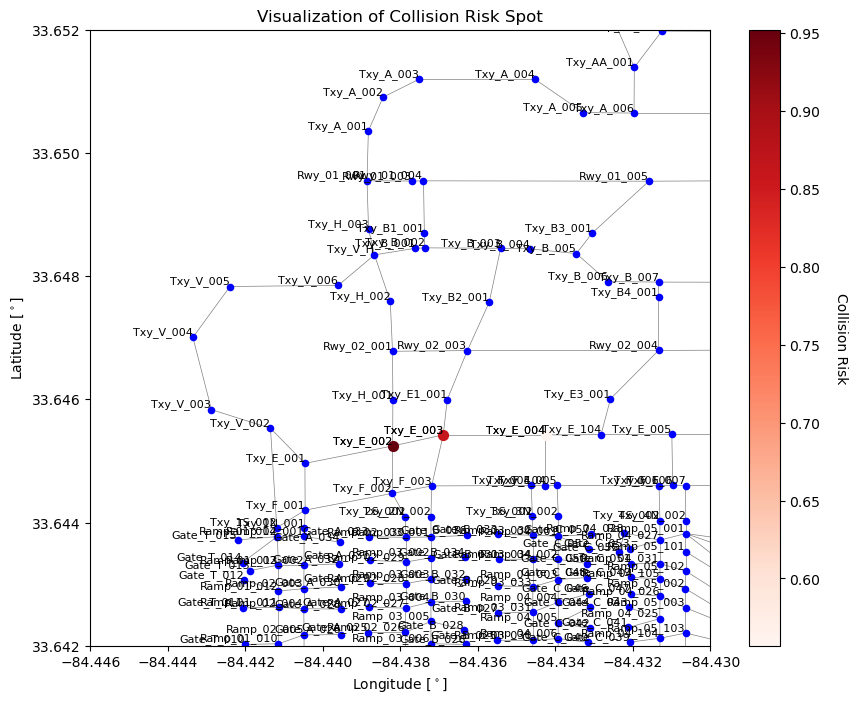

In [142]:
import matplotlib.pyplot as plt

def plot_collision_risk(ax, nodePositions, risk_values, nodes, cmap='viridis'):
    """
    Plots the collision risk on top of the background layout with node links color-mapped
    based on the calculated risk values.
    
    Parameters:
    - ax : matplotlib axis where to plot the background and risk values.
    - nodePositions : Dictionary with node ID as the key and tuple (lat, lon) as the value.
    - risk_values : List of risk values corresponding to the nodes.
    - nodes : List of node IDs to be visualized.
    - cmap : Colormap for the risk values.
    """
    # Normalize the risk values to scale the colormap
    norm = plt.Normalize(min(risk_values), max(risk_values))
    
    # Plot the nodes color-mapped by risk values
    for i, nodeId in enumerate(nodes):
        lat, lon = nodePositions[nodeId]
        risk = risk_values[i]
        
        # Plot the node with a color based on its risk value
        ax.scatter(lon, lat, color=plt.get_cmap(cmap)(norm(risk)), s=50, zorder=2)
        ax.text(lon, lat, nodeId, fontsize=8, ha='right', va='bottom', color='black', clip_on=True)
    
    # Add colorbar for risk values
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Empty array is fine for colorbar
    cbar = ax.figure.colorbar(sm, ax=ax)
    cbar.set_label('Collision Risk', rotation=270, labelpad=20)


# Create a figure with the layout and color-mapped nodes based on the risk values
fig, ax = plt.subplots(figsize=(10, 8))

# Assuming 'linksDf', 'nodePositions', and 'risk_values' are available from your previous code
# Plot the background layout (links, nodes)
nodes = pd.concat([
    linksDf[['n1.id', 'n1.lat', 'n1.lon']].rename(columns={'n1.id': 'id', 'n1.lat': 'lat', 'n1.lon': 'lon'}),
    linksDf[['n2.id', 'n2.lat', 'n2.lon']].rename(columns={'n2.id': 'id', 'n2.lat': 'lat', 'n2.lon': 'lon'})
]).drop_duplicates()
nodePositions = {row['id']: (row['lat'], row['lon']) for _, row in nodes.iterrows()}

draw_background(ax, linksDf, nodePositions, airport_name=ICAO, xlims=xlims, ylims=ylims)

# Define the nodes and corresponding risk values
nodes = intersection_nodes
risk_values = risk_results

# Plot collision risk for each node
plot_collision_risk(ax, nodePositions, risk_values, nodes, cmap='Reds')

# Show the plot
plt.title('Visualization of Collision Risk Spot')
plt.xlabel('Longitude [$^\circ$]')
plt.ylabel('Latitude [$^\circ$]')
plt.show()

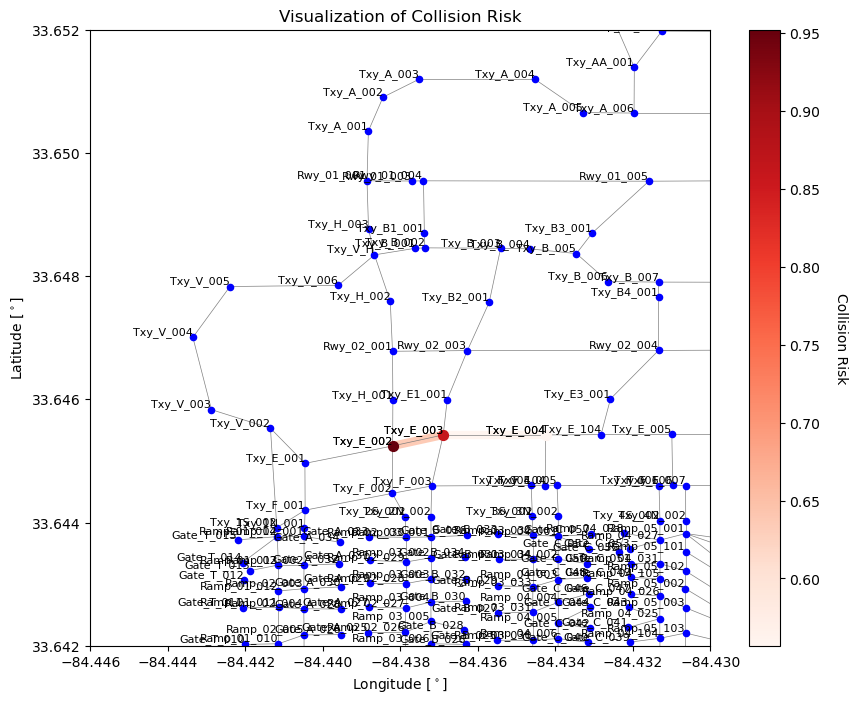

In [143]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_collision_risk(ax, linksDf, nodePositions, risk_values, nodes, cmap='viridis'):
    """
    Plots the collision risk on top of the background layout with nodes and
    the links connected to those nodes colored with a gradually reduced color.
    
    Parameters:
      ax            : matplotlib axis on which to plot.
      linksDf       : DataFrame with links (edges) between nodes.
      nodePositions : Dictionary with node ID as key and (lat, lon) as value.
      risk_values   : List of risk values corresponding to the nodes.
      nodes         : List of node IDs of interest.
      cmap          : Colormap to use.
    """
    # Normalize risk values for the colormap
    norm = plt.Normalize(min(risk_values), max(risk_values))
    
    # Create a dictionary mapping node IDs to their risk values.
    node_risk = dict(zip(nodes, risk_values))
    
    # Plot links only if both endpoints are in our region of interest.
    for _, row in linksDf.iterrows():
        node1_id = row['n1.id']
        node2_id = row['n2.id']
        
        # Skip the link if either node isn't in our region of interest.
        if node1_id not in node_risk or node2_id not in node_risk:
            continue
        
        # Also ensure the positions exist
        if node1_id not in nodePositions or node2_id not in nodePositions:
            continue
        
        node1_pos = nodePositions[node1_id]
        node2_pos = nodePositions[node2_id]
        
        # Compute the average risk for this link.
        avg_risk = (node_risk[node1_id] + node_risk[node2_id]) / 2
        
        # Use a fade factor to gradually reduce the color intensity.
        fade_factor = 0.7  # adjust as needed for more/less fading
        link_risk = avg_risk * fade_factor
        
        # Plot the link with a color based on the computed (faded) risk.
        ax.plot([node1_pos[1], node2_pos[1]], [node1_pos[0], node2_pos[0]],
                color=plt.get_cmap(cmap)(norm(link_risk)), linewidth=6, zorder=1)
    
    # Plot nodes with colors based on their risk values.
    for nodeId in nodes:
        if nodeId not in nodePositions:
            continue  # skip if the node is not available
        lat, lon = nodePositions[nodeId]
        risk = node_risk[nodeId]
        
        # Plot the node
        ax.scatter(lon, lat, color=plt.get_cmap(cmap)(norm(risk)), s=50, zorder=2)
        ax.text(lon, lat, nodeId, fontsize=8, ha='right', va='bottom',
                color='black', clip_on=True)
    
    # Add a colorbar to indicate risk values.
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Required for the colorbar to work properly.
    cbar = ax.figure.colorbar(sm, ax=ax)
    cbar.set_label('Collision Risk', rotation=270, labelpad=20)

# Create a figure with the layout and color-mapped nodes based on the risk values
fig, ax = plt.subplots(figsize=(10, 8))

# Assuming 'linksDf', 'nodePositions', and 'risk_values' are available from your previous code
# Plot the background layout (links, nodes)
nodes = pd.concat([
    linksDf[['n1.id', 'n1.lat', 'n1.lon']].rename(columns={'n1.id': 'id', 'n1.lat': 'lat', 'n1.lon': 'lon'}),
    linksDf[['n2.id', 'n2.lat', 'n2.lon']].rename(columns={'n2.id': 'id', 'n2.lat': 'lat', 'n2.lon': 'lon'})
]).drop_duplicates()
nodePositions = {row['id']: (row['lat'], row['lon']) for _, row in nodes.iterrows()}

draw_background(ax, linksDf, nodePositions, airport_name=ICAO, xlims=xlims, ylims=ylims)

# Define the nodes and corresponding risk values
nodes = intersection_nodes
risk_values = risk_results

# Plot collision risk for the selected nodes and their links.
plot_collision_risk(ax, linksDf, nodePositions, risk_values, nodes, cmap='Reds')

# Show the plot
plt.title('Visualization of Collision Risk')
plt.xlabel('Longitude [$^\circ$]')
plt.ylabel('Latitude [$^\circ$]')
plt.savefig('katl_accident_risk_map.png', dpi=300)
plt.show()


In [146]:
import math
import io
import os
import imageio
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# Helper functions
# ----------------------------

def get_position_along_path(path, nodePositions, speed, t):
    """
    Given a list of node IDs in 'path', returns the interpolated position (lat, lon)
    at simulation time t (in seconds), based on the aircraft's speed (mph).
    
    Speed is converted to miles per second (mps) via: mps = speed/3600.
    The function computes cumulative distances along the path and then finds the
    current segment and fraction traveled.
    """
    # Convert mph to miles per second
    mps = speed / 3600.0
    traveled_distance = mps * t

    # Compute cumulative distances along the path segments
    cum_distances = [0]
    for i in range(len(path) - 1):
        pos1 = nodePositions[path[i]]
        pos2 = nodePositions[path[i+1]]
        # Euclidean distance (ensure your coordinates are in a consistent scale)
        segment_distance = math.sqrt((pos2[0] - pos1[0])**2 + (pos2[1] - pos1[1])**2)
        cum_distances.append(cum_distances[-1] + segment_distance)
    total_distance = cum_distances[-1]

    # If we’ve passed the total distance, return the final node position.
    if traveled_distance >= total_distance:
        return nodePositions[path[-1]], total_distance

    # Otherwise, find the segment where the current traveled distance lies.
    for i in range(1, len(cum_distances)):
        if traveled_distance < cum_distances[i]:
            pos1 = nodePositions[path[i-1]]
            pos2 = nodePositions[path[i]]
            seg_distance = cum_distances[i] - cum_distances[i-1]
            seg_progress = (traveled_distance - cum_distances[i-1]) / seg_distance
            lat = pos1[0] + seg_progress * (pos2[0] - pos1[0])
            lon = pos1[1] + seg_progress * (pos2[1] - pos1[1])
            return (lat, lon), total_distance

def draw_background(ax, linksDf, nodePositions, airport_name, xlims=None, ylims=None):
    """
    Draws the airport layout (links and nodes) on the given axis, but only plots those
    nodes and links that are within the provided xlims (longitude limits) and ylims (latitude limits).
    
    Parameters:
      ax           : matplotlib axes on which to draw.
      linksDf      : DataFrame with taxiway/runway links.
      nodePositions: Dictionary of node positions keyed by node ID, with values as (lat, lon).
      airport_name : Name of the airport (used in the title).
      xlims        : Tuple (min_lon, max_lon) to set horizontal boundaries (optional).
      ylims        : Tuple (min_lat, max_lat) to set vertical boundaries (optional).
    """
    
    # Helper function to check if a point is within the limits.
    def is_within(lon, lat):
        within_x = True if xlims is None else (xlims[0] <= lon <= xlims[1])
        within_y = True if ylims is None else (ylims[0] <= lat <= ylims[1])
        return within_x and within_y

    # Draw taxiway/runway links.
    for _, row in linksDf.iterrows():
        # Ensure the coordinates are numbers (in case they were read as strings)
        try:
            n1_lon = float(row['n1.lon'])
            n1_lat = float(row['n1.lat'])
            n2_lon = float(row['n2.lon'])
            n2_lat = float(row['n2.lat'])
        except Exception as e:
            continue  # Skip row if conversion fails

        # Only draw this link if at least one endpoint is within the zoomed area.
        if (xlims is not None or ylims is not None) and not (is_within(n1_lon, n1_lat) or is_within(n2_lon, n2_lat)):
            continue
                
        ax.plot([n1_lon, n2_lon], [n1_lat, n2_lat],
                color='gray', linestyle='-', linewidth=0.5, clip_on=True)

    # Draw nodes and labels only if they are within the specified area.
    for nodeId, (lat, lon) in nodePositions.items():
        try:
            lat = float(lat)
            lon = float(lon)
        except Exception as e:
            continue  # Skip if conversion fails

        if (xlims is not None or ylims is not None) and not is_within(lon, lat):
            continue
        ax.scatter(lon, lat, color='blue', s=20, zorder=2, clip_on=True)
        ax.text(lon, lat, nodeId, fontsize=8, ha='right', va='bottom', clip_on=True)
        
    # Set the axis limits to enforce the zoom.
    if xlims is not None:
        ax.set_xlim(xlims)
    if ylims is not None:
        ax.set_ylim(ylims)
        
    ax.set_xlabel('Longitude [$^\circ$]')
    ax.set_ylabel('Latitude [$^\circ$]')
    ax.set_title(f'{airport_name} Layout')
    ax.grid(False)


def animate_two_aircraft(linksDf, nodePositions, path1, speed1, path2, speed2, airport_name, risk_values, intersect_nodes, output_filename, xlims=None, ylims=None):
    """
    Animates two aircraft moving along their respective paths at their given speeds,
    and compiles them into a single animated GIF.
    
    - path1, speed1: Path and speed (mph) for Japan Air 516.
    - path2, speed2: Path and speed (mph) for JA722A.
    - xlims: Optional tuple (min_lon, max_lon) to set the horizontal zoom.
    - ylims: Optional tuple (min_lat, max_lat) to set the vertical zoom.
    """
    
    # Helper to compute total path distance and travel time (in seconds)
    def compute_total_time(path, speed):
        total_distance = 0
        for i in range(len(path) - 1):
            pos1 = nodePositions[path[i]]
            pos2 = nodePositions[path[i+1]]
            segment_distance = math.sqrt((pos2[0] - pos1[0])**2 + (pos2[1] - pos1[1])**2)
            total_distance += segment_distance
        # Total travel time (in seconds) = (total_distance [miles] / speed [mph]) * 3600
        return int(math.ceil((total_distance / speed) * 3600))
    
    total_time1 = compute_total_time(path1, speed1)
    total_time2 = compute_total_time(path2, speed2)
    overall_total_time = max(total_time1, total_time2)

    frames = []
    for t in range(overall_total_time + 1):
        # Compute positions for both aircraft at time t.
        pos1, _ = get_position_along_path(path1, nodePositions, speed1, t)
        pos2, _ = get_position_along_path(path2, nodePositions, speed2, t)
        
        # Create a new figure for this frame.
        fig, ax = plt.subplots(figsize=(10, 10))
        # Set custom zoom (if provided) to focus on the area of interest.
        if xlims is not None:
            ax.set_xlim(xlims)
        if ylims is not None:
            ax.set_ylim(ylims)
            
        draw_background(ax, linksDf, nodePositions, airport_name, xlims=None, ylims=None)
        plot_collision_risk(ax, linksDf, nodePositions, risk_values, intersect_nodes, cmap='Reds')

        # Plot the planned paths.
        path1_lats = [nodePositions[node][0] for node in path1]
        path1_lons = [nodePositions[node][1] for node in path1]
        ax.plot(path1_lons, path1_lats, color='red', linestyle='--', linewidth=2, label='Endeavor 5526')
        
        path2_lats = [nodePositions[node][0] for node in path2]
        path2_lons = [nodePositions[node][1] for node in path2]
        ax.plot(path2_lons, path2_lats, color='green', linestyle='--', linewidth=2, label='Delta 295')
        
        # Plot the current positions.
        ax.scatter(pos1[1], pos1[0], color='red', s=50, zorder=3, label='Endeavor 5526' if t==0 else "")
        ax.scatter(pos2[1], pos2[0], color='green', s=50, zorder=3, label='Delta 295' if t==0 else "")
        
        # Display simulation time.
        ax.text(0.05, 0.95, f"t = {t} s", transform=ax.transAxes,
                fontsize=12, color='black', verticalalignment='top')
        
        # Add legend (only once).
        ax.legend(loc='upper right')
        
        # Save the frame to a buffer.
        buf = io.BytesIO()
        plt.savefig(buf, format='png')
        plt.close(fig)
        buf.seek(0)
        image = imageio.imread(buf)
        frames.append(image)

    # Save all frames as an animated GIF.
    imageio.mimsave(output_filename, frames, duration=0.1)
    print(f"Animation saved to {output_filename}")

# ----------------------------
# Example usage
# ----------------------------

# Define your airport identifier (e.g., ICAO code)
# Load the airport layout data.
# The CSV is assumed to have columns: n1.id, n1.lat, n1.lon, n2.id, n2.lat, n2.lon.
filePath = os.path.join(os.getcwd(), 'Airport Layouts', ICAO + '_Nodes_Links.csv')
linksDf = pd.read_csv(filePath)

# Compute nodePositions from linksDf.
nodes = pd.concat([
    linksDf[['n1.id', 'n1.lat', 'n1.lon']].rename(columns={'n1.id': 'id', 'n1.lat': 'lat', 'n1.lon': 'lon'}),
    linksDf[['n2.id', 'n2.lat', 'n2.lon']].rename(columns={'n2.id': 'id', 'n2.lat': 'lat', 'n2.lon': 'lon'})
]).drop_duplicates()
nodePositions = {row['id']: (row['lat'], row['lon']) for _, row in nodes.iterrows()}

# --- Define Aircraft Paths and Speeds ---

# EDV 5526
path_edv = path1[0][0]
speed_edv = 2/3  # mph

# DELTA 295
path_delta = path2[0][0]
speed_delta = 2.5/3  # mph

# Set the axis limits to zoom in on the area near the holding points.
# Replace these with the appropriate values for your area of interest.
# Example: xlims = (min_lon, max_lon) and ylims = (min_lat, max_lat)
xlims = (-84.446, -84.430)  # Example longitude limits
ylims = (33.642, 33.652)    # Example latitude limits
# xlims = None # Example longitude limits
# ylims = None    # Example latitude limits

# Create a single animation showing both aircraft.
animate_two_aircraft(
    linksDf=linksDf,
    nodePositions=nodePositions,
    path1=path_edv,
    speed1=speed_edv,
    path2=path_delta,
    speed2=speed_delta,
    airport_name=ICAO,
    risk_values=risk_results, 
    intersect_nodes=intersection_nodes,
    output_filename='case-study-2-riskmap.gif',
    xlims=xlims,
    ylims=ylims
)

/tmp/ipykernel_3349798/1529620657.py:181: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(buf)
